# GPU Phasemask Generation Testing

---
#### Baseline

In [1]:
import numpy as np
from pytweezer import phasemask as pm

In [4]:
PM = pm.OptimisationBasedPhasemaskGeneratorGPU(
                 wavelength_um=0.852,
                 focal_length_mm=10.0,
                 slm_pitch_um=8,
                 slm_res=(1200,1920),
                 input_beam_waist_mm=9.6)

W = np.ones((8, 8))
spacing_um = 5

target = PM.generate_weighted_array(W, spacing_um, init_phase_randomness=1.0)
pm_slm, terms, metrics = PM.superposition_optimization(target, max_iter=500, damping=0.5, verbose=True)

--- System Configuration ---
SLM Plane Width: 15.36 mm
SLM Plane Height: 9.60 mm
Focal Plane Resolution x (pixel size): 0.5547 um
Focal Plane Resolution y (pixel size): 0.8875 um
Focal Plane Width: 1065.00 um
Focal Plane Height: 1065.00 um
--- Target Generation ---
Grid: 8x8
Spacing: 5 um
--- Starting GPU Superposition Phase Retrieval ---
Iteration 000 | Mean-Squared Error: 4.31e-05 | Uniformity: 57.97% | Min/Max ratio: 0.085
Iteration 010 | Mean-Squared Error: 1.67e-07 | Uniformity: 97.39% | Min/Max ratio: 0.872
Iteration 020 | Mean-Squared Error: 1.79e-07 | Uniformity: 97.30% | Min/Max ratio: 0.883
Iteration 030 | Mean-Squared Error: 7.57e-08 | Uniformity: 98.24% | Min/Max ratio: 0.928
Iteration 040 | Mean-Squared Error: 4.48e-08 | Uniformity: 98.64% | Min/Max ratio: 0.943
Iteration 050 | Mean-Squared Error: 7.88e-08 | Uniformity: 98.20% | Min/Max ratio: 0.920
Iteration 060 | Mean-Squared Error: 8.50e-09 | Uniformity: 99.41% | Min/Max ratio: 0.973
Iteration 070 | Mean-Squared Error: 

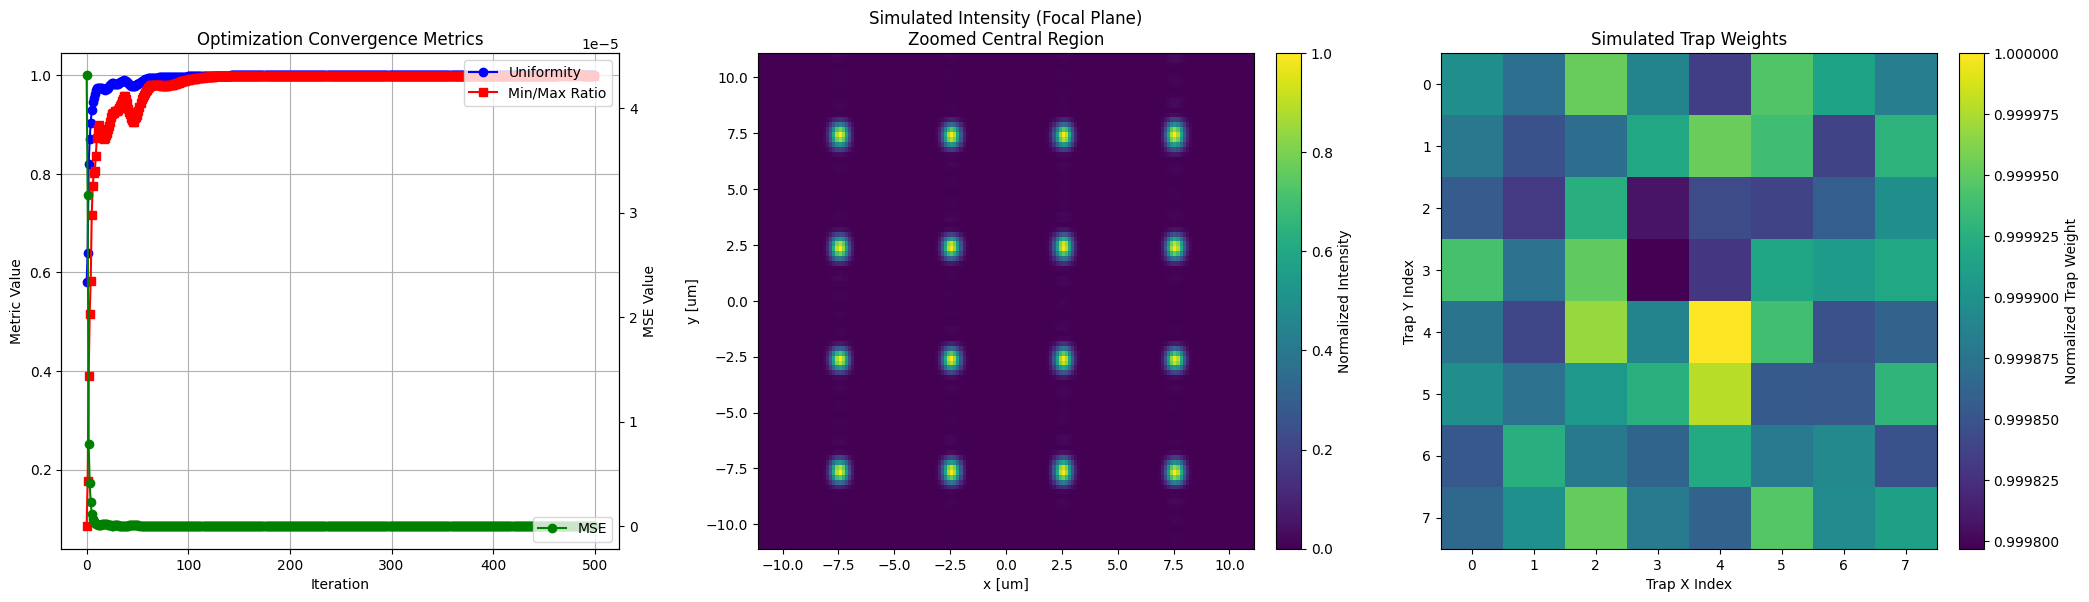

In [5]:
PM.visualise_algorithm_performance(pm_slm, metrics, 20, pad=4)

In [6]:
from pytweezer import communication as comm

phasemask_8bit = PM.transform_phase_8bit(pm_slm)

SLM = comm.SLMClient()
SLM.update_mask(phasemask_8bit)

{'status': 'success', 'msg': 'Mask updated successfully.'}